In [36]:
from pathlib import Path
import matplotlib.pyplot as plt
from napari import Viewer

import torch
import urllib3
from scipy.spatial.transform import Rotation
from torch_fourier_shell_correlation import fourier_shell_correlation
from ttsim3d.models import Simulator, SimulatorConfig
from torch_fourier_filter.dose_weight import dose_weight_2d
from torch_ctf import calculate_ctf_2d
from torch_grid_utils import fftfreq_grid
from torch_fourier_slice import (
    backproject_2d_to_3d,
    project_3d_to_2d,
)

PDB_ID = "4v6x"  # 80S ribosome
PIXEL_SPACING = 10.0  # angstroms per pixel -> Nyquist at 20.0 A
VOLTAGE = 300  # in keV
BOX = 128  # 1280 A box
SNR = 0.1  # signal-to-noise (variance ratio) of the noisy projections
CACHE = Path.home() / ".cache" / "arp"
TILT_ANGLES = torch.arange(-54, 57, 3)
DOSE = [
    82.2, 79.8, 70.68, 68.4, 66.12, 54.72, 52.44, 50.16, 47.88, 41.04, 38.76, 31.92,
    29.64, 22.8, 20.52, 13.68, 11.4, 4.56, 2.28, 0, 6.84, 9.12,
    15.96, 18.24, 25.08, 27.36, 34.2, 36.48, 43.32, 45.6, 57, 59.28,
    61.559998, 63.84, 72.96, 75.24, 77.52
] # total dose over tilt-series in e-/A^2


def simulate_ribosome() -> torch.Tensor:
    """Download the PDB entry and simulate its density map (cached on disk)."""
    CACHE.mkdir(parents=True, exist_ok=True)
    volume_path = CACHE / f"{PDB_ID}_box{BOX}_{PIXEL_SPACING:g}apx.pt"
    if volume_path.exists():
        return torch.load(volume_path)

    structure_path = CACHE / f"{PDB_ID}.cif"
    if not structure_path.exists():
        print(f"downloading {PDB_ID} from RCSB (~28 MB, once) ...")
        response = urllib3.PoolManager().request(
            "GET", f"https://files.rcsb.org/download/{PDB_ID}.cif"
        )
        structure_path.write_bytes(response.data)

    print(f"simulating a {BOX}^3 volume at {PIXEL_SPACING} A/px ...")
    simulator = Simulator(
        pdb_filepath=str(structure_path),
        pixel_spacing=PIXEL_SPACING,
        volume_shape=(BOX, BOX, BOX),
        b_factor_scaling=1.0,
        additional_b_factor=0.0,
        simulator_config=SimulatorConfig(
            voltage=300.0,
            apply_dose_weighting=False,
            dose_start=0.0,
            dose_end=35.0,
            upsampling=4,
        ),
    )
    volume = simulator.run()
    torch.save(volume, volume_path)
    return volume

# get the ribosome density
ribosome = simulate_ribosome()

# generate a CTF image
ctf_values = {
    "defocus": 3,  # in micrometers
    "astigmatism": 0.0,  # in micrometers
    "astigmatism_angle": 0.0,  # in degrees
    "voltage": VOLTAGE,  # in volts
    "spherical_aberration": 2.7, # mm float | torch.Tensor,
    "amplitude_contrast": 0.07, # float | torch.Tensor,
    "phase_shift": 0.0, # float | torch.Tensor,
    "pixel_size": PIXEL_SPACING, # float | torch.Tensor,
    "image_shape": (BOX, BOX), # tuple[int, int],
    "rfft": True, # bool,
    "fftshift": False, # bool,
    "beam_tilt_mrad": None, # torch.Tensor | None = None,
    "even_zernike_coeffs": None, # dict | None = None,
    "odd_zernike_coeffs": None, # dict | None = None,
    "transform_matrix": None, # torch.Tensor | None = None,
    "return_complex_ctf": False, # bool = False, 
}
# need to add minus sign for correct CTF, weird...
ctf_image = - calculate_ctf_2d(**ctf_values)

# cut-off beyond nyquist
frequency_grid = fftfreq_grid(image_shape=(BOX, BOX), rfft=True, fftshift=False, norm=True)
ctf_image[frequency_grid > 0.5] = 0

# create dose weighted CTF's
dose_per_tilt = torch.Tensor(DOSE)
ctf_per_tilt = dose_weight_2d(
    image_dft=ctf_image.repeat(len(DOSE), 1, 1),
    image_shape=(BOX, BOX),
    pixel_size=PIXEL_SPACING,
    dose=dose_per_tilt,
    voltage=VOLTAGE,
)


## Simulate a single projection image

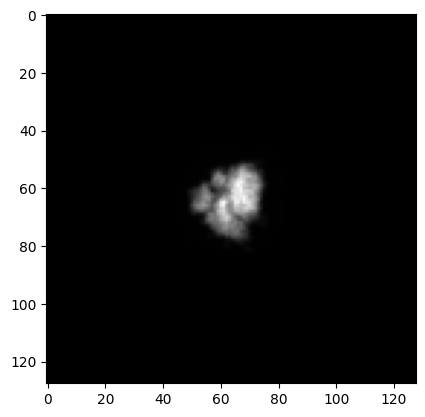

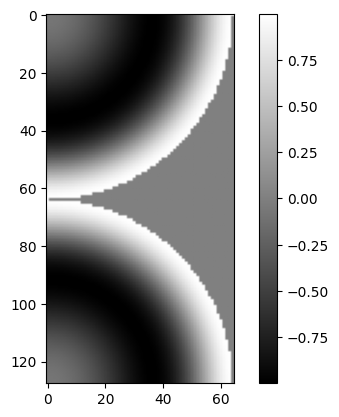

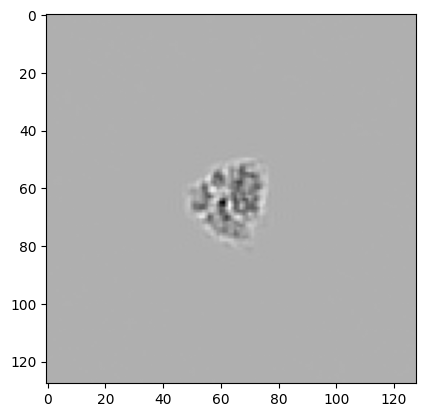

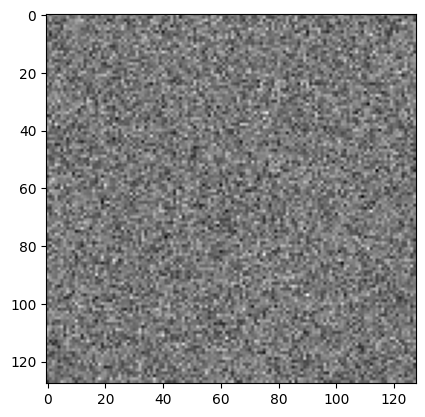

In [37]:
projection = ribosome.sum(dim=0)
convolved = torch.fft.irfftn(torch.fft.rfftn(projection) * ctf_image)
noisy = convolved + torch.normal(mean=0, std=SNR, size=(convolved.shape))

plt.imshow(projection, cmap='gray')
plt.show()
plt.imshow(ctf_image, cmap='gray')
plt.colorbar()
plt.show()
plt.imshow(convolved, cmap='gray')
plt.show()
plt.imshow(noisy, cmap='gray')
plt.show()

In [38]:
viewer = Viewer()
viewer.add_image(ctf_image.numpy())

<Image layer 'Image' at 0x7bd389dad590>